In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt

# Set SVG font type to 'none' to keep text as text in SVG files
plt.rcParams["svg.fonttype"] = "none"

In [3]:
FIGURES_FOLDER = "/home/nathanl/scviva_paper/merfish_brain/synthetic_gene"

# Add a new alpha, then correlate the gene

In [4]:
import numpy as np
import anndata as ad
import numpy as np
import pandas as pd
from sklearn.preprocessing import minmax_scale
from scipy.stats import pearsonr


def generate_integer_gene(alpha: np.ndarray, correlation: float = 0.99, target_mean: float = 10, seed: int = 42):
    """
    Generate an integer-valued synthetic gene expression vector correlated with alpha,
    with a specified target mean expression.

    Parameters:
        alpha (np.ndarray): The reference vector (e.g., cell-type proportion).
        correlation (float): Desired Pearson correlation (0 < corr <= 1).
        target_mean (float): Desired mean of the resulting gene expression (in counts).
        seed (int): Random seed.

    Returns:
        np.ndarray: Integer-valued gene expression vector.
    """
    rng = np.random.default_rng(seed)

    # Standardize alpha
    alpha_std = (alpha - np.mean(alpha)) / np.std(alpha)

    # Generate independent noise
    noise = rng.normal(0, 1, len(alpha))
    noise_std = (noise - np.mean(noise)) / np.std(noise)

    # Create synthetic gene vector
    gene = correlation * alpha_std + np.sqrt(1 - correlation**2) * noise_std

    # Rescale to positive and match mean
    gene = gene - np.min(gene)
    gene = gene / np.mean(gene) * target_mean

    # Round to integer counts
    gene_int = np.round(gene).astype(int)
    return gene_int


def generate_alpha(
    composition_df: pd.DataFrame,
    mode: str = "random",  # "random" or "correlated"
    lower_bound: float = 0.0,
    upper_bound: float = 1.0,
    column_to_correlate: str = None,
    noise_level: float = 0.0,  # 0 = perfectly correlated, >0 adds noise
    random_state: int = None,
) -> tuple[np.ndarray, float | None]:
    """
    Generate a synthetic alpha vector.

    Returns:
        (alpha vector, correlation with column if mode='correlated' else None)
    """
    rng = np.random.default_rng(random_state)

    if mode == "random":
        alpha = rng.uniform(lower_bound, upper_bound, size=composition_df.shape[0])
        return alpha, None

    elif mode == "correlated":
        if column_to_correlate is None:
            raise ValueError("You must specify column_to_correlate when using 'correlated' mode.")
        if column_to_correlate not in composition_df.columns:
            raise ValueError(f"Column '{column_to_correlate}' not found in composition_df.")

        raw = composition_df[column_to_correlate].values
        scaled = minmax_scale(raw, feature_range=(lower_bound, upper_bound))

        if noise_level > 0:
            noise = rng.normal(0, noise_level, size=scaled.shape)
            alpha = scaled + noise
            alpha = np.clip(alpha, lower_bound, upper_bound)
        else:
            alpha = scaled

        correlation = pearsonr(alpha, raw)[0]
        print(f"Generated alpha correlated with '{column_to_correlate}' (r={correlation:.3f})")
        return alpha

    else:
        raise ValueError("Invalid mode. Choose 'random' or 'correlated'.")

In [5]:
adata = ad.read_h5ad("/home/nathanl/Data/adata_M1_M2_core_6_sections.h5ad")
adata

AnnData object with n_obs × n_vars = 250790 × 1122
    obs: 'organism_ontology_term_id', 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_counts', 'batch', '_scvi_batch', '_scvi_labels', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'p

In [6]:
print(adata.obsm)

AxisArrays with keys: X_CCF, X_banksy_02_harmony, X_banksy_02_harmony_GABAergic, X_banksy_02_harmony_astrocyte, X_banksy_02_harmony_endothelial, X_banksy_02_harmony_glutamatergic, X_banksy_02_harmony_microglial, X_banksy_02_harmony_oligodendrocyte, X_banksy_02_harmony_oligodendrocyte_precursor, X_banksy_02_harmony_pericyte, X_nicheformer, X_nicheformer_e5, X_pca, X_resolvi, X_resolvi_MDE, X_spatial, X_umap, banksy_pc_20_lambda_0.0, banksy_pc_20_lambda_0.0_GABAergic, banksy_pc_20_lambda_0.0_astrocyte, banksy_pc_20_lambda_0.0_endothelial, banksy_pc_20_lambda_0.0_glutamatergic, banksy_pc_20_lambda_0.0_microglial, banksy_pc_20_lambda_0.0_oligodendrocyte, banksy_pc_20_lambda_0.0_oligodendrocyte_precursor, banksy_pc_20_lambda_0.0_pericyte, banksy_pc_20_lambda_0.2, banksy_pc_20_lambda_0.2_GABAergic, banksy_pc_20_lambda_0.2_astrocyte, banksy_pc_20_lambda_0.2_endothelial, banksy_pc_20_lambda_0.2_glutamatergic, banksy_pc_20_lambda_0.2_microglial, banksy_pc_20_lambda_0.2_oligodendrocyte, banksy_p

### Building the new Adatas

In [29]:
adata.X.todense().mean(axis=0).max()

np.float64(4.191068224410862)

In [6]:
from scvi.external import SCVIVA
from params_positive import setup

setup_kwargs = {
    "sample_key": setup.SAMPLE,
    "labels_key": setup.CELL_TYPE,
    "cell_coordinates_key": setup.COORDS,
    "expression_embedding_key": "X_resolvi",
    "expression_embedding_niche_key": "qz1_m_niche_ct",
    "niche_composition_key": "neighborhood_composition",
    "niche_indexes_key": "niche_indexes",
    "niche_distances_key": "niche_distances",
}
SCVIVA.preprocessing_anndata(
    adata,
    k_nn=20,
    **setup_kwargs,
)

Saved niche_indexes and niche_distances in adata.obsm

Saved neighborhood_composition in adata.obsm

Saved qz1_m_niche_ct in adata.obsm

In [7]:
alpha_synthetic = generate_alpha(
    composition_df=adata.obsm["neighborhood_composition"],
    mode="correlated",
    column_to_correlate="oligodendrocyte",
    noise_level=0.3,
    random_state=42,
    upper_bound=0.25,
)


# Copy the existing neighborhood composition matrix
composition_df = adata.obsm["neighborhood_composition"].copy()

# Add the new synthetic alpha
composition_df["synthetic_cell_type"] = alpha_synthetic

# Renormalize each row to sum to 1
composition_normalized = composition_df.div(composition_df.sum(axis=1), axis=0)

# Store in .obsm
adata.obsm["neighborhood_composition_w_synth"] = composition_normalized


# Original tensor
tensor = adata.obsm["qz1_m_niche_ct"]  # shape: (n_cells, n_types, n_latent)

# Create zeros of shape (n_cells, 1, n_latent)
zero_pad = np.zeros((tensor.shape[0], 1, tensor.shape[2]), dtype=tensor.dtype)

# Concatenate along the cell type (n_types) axis
expanded_tensor = np.concatenate([tensor, zero_pad], axis=1)

# Store back
adata.obsm["qz1_m_niche_ct_w_synth"] = expanded_tensor

Generated alpha correlated with 'oligodendrocyte' (r=0.156)


In [8]:
mean_gene_expression = adata.layers["counts"].mean()

rng = np.random.default_rng(seed=42)  # for reproducibility
correlations = rng.uniform(0.85, 0.95, size=1)  

gene_expression_synthetic_matrix = np.vstack(
    [
        generate_integer_gene(
            alpha=alpha_synthetic,
            correlation=corr,
            target_mean=1.8,
            seed=i,
        )
        for i, corr in enumerate(correlations)
    ]
).T

gene_expression_synthetic_matrix_names = [f"synthetic_gene_{i+1}" for i in range(gene_expression_synthetic_matrix.shape[1])]

# Wrap the synthetic gene in an AnnData object
adata_synthetic = ad.AnnData(X=gene_expression_synthetic_matrix)
adata_synthetic.var_names = gene_expression_synthetic_matrix_names
adata_synthetic.obs_names = adata.obs_names  # Important: must match adata

adata.X = adata.raw.X.copy()

# Concatenate along genes (variables)
adata_both = ad.concat([adata, adata_synthetic], axis=1, join="outer")

for i in range(gene_expression_synthetic_matrix.shape[1]):
    adata_both.var.loc[f"synthetic_gene_{i+1}", "gene_name"] = f"synthetic_gene_{i+1}"

# Restore original .obs
adata_both.obs = adata.obs.copy()
adata_both.obsm = adata.obsm.copy()
adata_both.layers["counts"] = adata_both.X.copy()

/home/nathanl/miniforge3/envs/scvi/lib/python3.12/site-packages/anndata/_core/merge.py:1434: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(


In [9]:
gene_expression_synthetic_matrix.max()

np.int64(4)

Text(0, 0.5, 'Frequency')

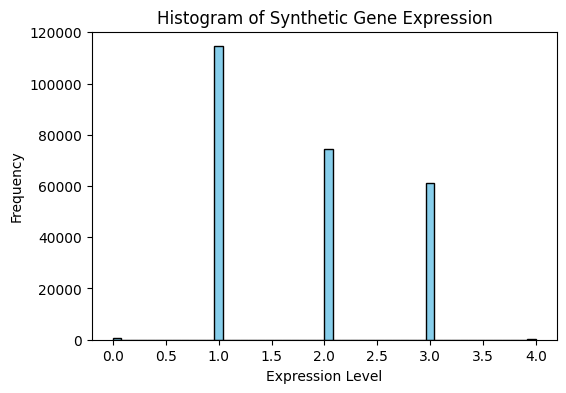

In [19]:
from matplotlib import pyplot as plt

plt.figure(figsize=(6, 4))
plt.hist(gene_expression_synthetic_matrix[:,0], bins=50, color="skyblue", edgecolor="black")
plt.title("Histogram of Synthetic Gene Expression")
plt.xlabel("Expression Level")
plt.ylabel("Frequency")

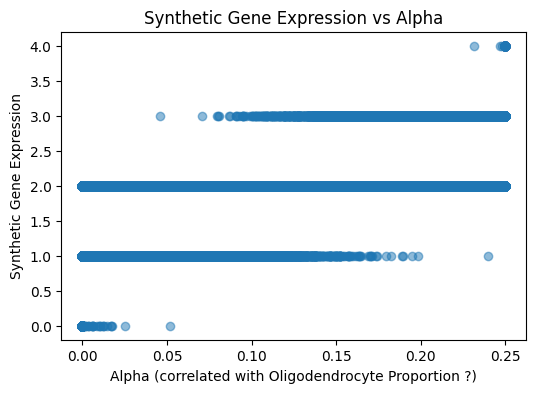

In [20]:
plt.figure(figsize=(6, 4))
plt.scatter(alpha_synthetic, gene_expression_synthetic_matrix[:,0], alpha=0.5)
plt.title("Synthetic Gene Expression vs Alpha")
plt.xlabel("Alpha (correlated with Oligodendrocyte Proportion ?)")
plt.ylabel("Synthetic Gene Expression")
plt.show()

In [12]:
adata_both.var

,gene_name,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,mt,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
ENSMUSG00000024798,Htr7,False,Htr7,NCBITaxon:10090,gene,3399,False,28055.0,0.481863,0.393300,88.813350,120846.250000,11.702283
ENSMUSG00000042385,Gzmk,False,Gzmk,NCBITaxon:10090,gene,1389,False,1485.0,0.024880,0.024575,99.407871,6239.541016,8.738822
ENSMUSG00000036198,Arhgap36,False,Arhgap36,NCBITaxon:10090,gene,3421,False,10856.0,0.194917,0.178077,95.671279,48883.355469,10.797213
ENSMUSG00000028780,Sema3c,False,Sema3c,NCBITaxon:10090,gene,7140,False,30254.0,0.568603,0.450186,87.936521,142600.593750,11.867810
ENSMUSG00000015843,Rxrg,False,Rxrg,NCBITaxon:10090,gene,2297,False,21148.0,0.364153,0.310533,91.567447,91325.578125,11.422197
...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000070047,Fat1,False,Fat1,NCBITaxon:10090,gene,15655,False,55281.0,1.002240,0.694266,77.957255,251351.609375,12.434612
ENSMUSG00000002266,Zim1,False,Zim1,NCBITaxon:10090,gene,8086,False,19558.0,0.339419,0.292236,92.201443,85122.953125,11.351864
ENSMUSG00000036111,Lmo1,False,Lmo1,NCBITaxon:10090,gene,1552,False,14579.0,0.249288,0.222574,94.186770,62519.199219,11.043245
ENSMUSG00000033063,Cntnap3,False,Cntnap3,NCBITaxon:10090,gene,6386,False,10162.0,0.166813,0.154276,95.948004,41835.156250,10.641517


In [13]:
adata.obsm["qz1_m_niche_ct_w_synth"].shape

(250790, 18, 10)

In [14]:
adata_both.obsm["neighborhood_composition_w_synth"]

,oligodendrocyte,endothelial cell,astrocyte,oligodendrocyte_precursor cell,GABAergic neuron,microglial cell,glutamatergic neuron,pericyte,macrophage,vascular leptomeningeal cell,tanycyte,smooth muscle cell,lymphocyte,neuroblast (sensu Vertebrata),dopaminergic neuron,choroid plexus epithelial cell,ependymal cell,synthetic_cell_type
99119258951401284221813451836785008968-0,0.175221,0.219026,0.219026,0.00,0.175221,0.00,0.043805,0.043805,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.123895
95610536408155075407048305276227824006-0,0.200000,0.100000,0.050000,0.05,0.450000,0.00,0.100000,0.050000,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
94627996433995692958551448758698866723-0,0.200000,0.080000,0.200000,0.08,0.080000,0.08,0.040000,0.040000,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.200000
10618021078266319649091845116122351158-0,0.280000,0.040000,0.080000,0.00,0.240000,0.08,0.000000,0.080000,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.200000
89038554173344823793949504602728291142-0,0.350000,0.300000,0.100000,0.00,0.200000,0.05,0.000000,0.000000,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198804031042921944377635730961789487507-1,0.000000,0.120000,0.240000,0.12,0.080000,0.04,0.080000,0.080000,0.04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.200000
156934588469937564968781740624428245657-1,0.000000,0.120000,0.200000,0.12,0.080000,0.04,0.080000,0.120000,0.04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.200000
155321557493369021799199720361468240742-1,0.000000,0.080000,0.320000,0.04,0.080000,0.04,0.120000,0.080000,0.04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.200000
24226418575755266420023086883481701930-1,0.000000,0.160000,0.240000,0.20,0.080000,0.04,0.040000,0.040000,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.200000


add L1 loss for the GENE - get posterior params and check the get_likelihood_parameters

In [34]:
adata_both.layers["counts"].todense()[:, 11].max()

np.float64(57.0)

In [25]:
# adata_both.write_h5ad("/home/nathanl/Data/adata_M1_M2_core_6_sections_with_synthetic_gene.h5ad")

check the loss

<!-- mean = model.get_likelihood_parameters(adata, give_mean=True)["mean"]
np.save("mean_expression.npy", mean) -->

### MAE with synthetic type

In [10]:
import nichevi
import os
from params_positive import setup
import anndata as ad


compo_synth = adata.obsm["neighborhood_composition_w_synth"]["synthetic_cell_type"]

data_dir, data_file = setup.DATA_FOLDER, setup.DATA_FILE
data_file_name = os.path.splitext(data_file)[0]
print(data_file_name)
path_to_save = os.path.join("/home/nathanl/scviva_paper/merfish_brain/checkpoints/", data_file_name)


setting = f"1g_synth_eta0_{setup.EXPRESSION_MODEL}_lr{str(setup.LR_NICHEVI)}_{setup.LIKELIHOOD}"
path_to_save_nichevae = path_to_save + "/nichevae_" + setting + "_" + str(setup.N_EPOCHS_NICHEVI) + ".pt"
print(path_to_save_nichevae)
nichevae = nichevi.nicheSCVI.load(
    dir_path=path_to_save_nichevae,
    # adata=adata,
)
adata = ad.read_h5ad(
    os.path.join(path_to_save_nichevae, "adata.h5ad"),
)
print(adata.shape)
print(adata.obsm["neighborhood_composition"].shape)

ll_dict = nichevae.get_likelihood_parameters(n_samples=10)  # posteriror sampling here !!!!
# Get boolean mask for synthetic genes
synthetic_mask = adata.var_names.str.startswith("synthetic_gene_")
# Get column indices of synthetic genes
synthetic_indices = np.where(synthetic_mask)[0]
# Get predicted expression (mean over posterior samples)
predicted_expression_synthetic = ll_dict["mean"].mean(axis=0)[:, synthetic_indices]

# # Get index of the synthetic gene
# gene_idx = adata.var_names.get_loc("synthetic_gene_1")

# # Get observed counts for the synthetic gene
observed_counts = adata.layers["counts"][:, synthetic_indices].toarray()
# observed_counts_std = observed_counts.std() + 1e-8  # avoid division by zero

# # observed_counts = (observed_counts - observed_counts.mean()) / observed_counts_std

observed_all = adata.layers["counts"].toarray()
observed_all_no_synth = np.delete(observed_all, synthetic_indices, axis=1)
# observed_all_no_synth_std = observed_all_no_synth.std(axis=0) + 1e-8  # avoid division by zero

# # observed_all_no_synth = (observed_all_no_synth - observed_all_no_synth.mean(axis=0)) / observed_all_no_synth_std

predicted_all = ll_dict["mean"].mean(axis=0)
predicted_all_no_synth = np.delete(predicted_all, synthetic_indices, axis=1)
# # predicted_all_no_synth = (predicted_all_no_synth - predicted_all_no_synth.mean(axis=0)) / (
# #     predicted_all_no_synth.std(axis=0) + 1e-8
# # )


# # Compute MAE
mae_synth = np.abs(observed_counts - predicted_expression_synthetic)  #.mean(axis=0)
mae_all_genes_synth = np.abs(observed_all_no_synth - predicted_all_no_synth).mean(axis=0)
mae_mean = mae_synth.mean()
print(f"MAE for synthetic_genes: {mae_mean:.4f}")
mae_mean_all = mae_all_genes_synth.mean()
print(f"MAE for all other genes: {mae_mean_all:.4f}")

from scipy.stats import pearsonr

# Flatten in case either input is shaped like (N, 1) or (1, N)
alpha_flat = np.ravel(compo_synth)
pred_flat = np.ravel(predicted_expression_synthetic)

# Check shapes match
assert alpha_flat.shape == pred_flat.shape, "Shape mismatch between alpha and predicted expression"

# Compute Pearson correlation
r, p_value = pearsonr(alpha_flat, pred_flat)
print(f"Pearson r = {r:.3f}, p = {p_value:.2e}")

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


adata_M1_M2_core_6_sections_with_synthetic_gene
/home/nathanl/scviva_reproducibility/brain/checkpoints/adata_M1_M2_core_6_sections_with_synthetic_gene/nichevae_1g_synth_eta0_scanvi_lr0.0005_poisson_1001.pt
INFO     File                                                                                                      
         /home/nathanl/scviva_reproducibility/brain/checkpoints/adata_M1_M2_core_6_sections_with_synthetic_gene/nic
         hevae_1g_synth_eta0_scanvi_lr0.0005_poisson_1001.pt/model.pt already downloaded                           
(250790, 1123)
(250790, 18)
MAE for synthetic_genes: 0.8136
MAE for all other genes: 0.1646
Pearson r = 0.424, p = 0.00e+00


### MAE wo/ synthetic type

In [11]:
setting = f"1g_eta0_{setup.EXPRESSION_MODEL}_lr{str(setup.LR_NICHEVI)}_{setup.LIKELIHOOD}"
path_to_save_nichevae = path_to_save + "/nichevae_" + setting + "_" + str(setup.N_EPOCHS_NICHEVI) + ".pt"
print(path_to_save_nichevae)
nichevae = nichevi.nicheSCVI.load(
    dir_path=path_to_save_nichevae,
)
adata = ad.read_h5ad(
    os.path.join(path_to_save_nichevae, "adata.h5ad"),
)
print(adata.shape)
print(adata.obsm["neighborhood_composition"].shape)

ll_dict = nichevae.get_likelihood_parameters(n_samples=10)  # posteriror sampling here !!!!
# Get boolean mask for synthetic genes
synthetic_mask = adata.var_names.str.startswith("synthetic_gene_")
# Get column indices of synthetic genes
synthetic_indices = np.where(synthetic_mask)[0]
# Get predicted expression (mean over posterior samples)
predicted_expression_synthetic = ll_dict["mean"].mean(axis=0)[:, synthetic_indices]

# # Get index of the synthetic gene
# gene_idx = adata.var_names.get_loc("synthetic_gene_1")

# # Get observed counts for the synthetic gene
observed_counts = adata.layers["counts"][:, synthetic_indices].toarray()
# observed_counts_std = observed_counts.std() + 1e-8  # avoid division by zero

# # observed_counts = (observed_counts - observed_counts.mean()) / observed_counts_std

observed_all = adata.layers["counts"].toarray()
observed_all_no_synth = np.delete(observed_all, synthetic_indices, axis=1)
# observed_all_no_synth_std = observed_all_no_synth.std(axis=0) + 1e-8  # avoid division by zero

# # observed_all_no_synth = (observed_all_no_synth - observed_all_no_synth.mean(axis=0)) / observed_all_no_synth_std

predicted_all = ll_dict["mean"].mean(axis=0)
predicted_all_no_synth = np.delete(predicted_all, synthetic_indices, axis=1)
# # predicted_all_no_synth = (predicted_all_no_synth - predicted_all_no_synth.mean(axis=0)) / (
# #     predicted_all_no_synth.std(axis=0) + 1e-8
# # )

# Compute MAE
mae_random = np.abs(observed_counts - predicted_expression_synthetic) #.mean(axis=0)
mae_all_genes_random = np.abs(observed_all_no_synth - predicted_all_no_synth).mean(axis=0)
mae_mean = mae_random.mean()
print(f"MAE for synthetic_genes: {mae_mean:.4f}")
mae_mean_all = mae_all_genes_random.mean()
print(f"MAE for all other genes: {mae_mean_all:.4f}")

# Flatten in case either input is shaped like (N, 1) or (1, N)
alpha_flat = np.ravel(compo_synth)
pred_flat = np.ravel(predicted_expression_synthetic)

# Check shapes match
assert alpha_flat.shape == pred_flat.shape, "Shape mismatch between alpha and predicted expression"

# Compute Pearson correlation
r, p_value = pearsonr(alpha_flat, pred_flat)
print(f"Pearson r = {r:.3f}, p = {p_value:.2e}")

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


/home/nathanl/scviva_reproducibility/brain/checkpoints/adata_M1_M2_core_6_sections_with_synthetic_gene/nichevae_1g_eta0_scanvi_lr0.0005_poisson_1001.pt
INFO     File                                                                                                      
         /home/nathanl/scviva_reproducibility/brain/checkpoints/adata_M1_M2_core_6_sections_with_synthetic_gene/nic
         hevae_1g_eta0_scanvi_lr0.0005_poisson_1001.pt/model.pt already downloaded                                 


(250790, 1123)
(250790, 17)
MAE for synthetic_genes: 1.0068
MAE for all other genes: 0.1636
Pearson r = 0.036, p = 1.33e-71


### MAE for the other genes

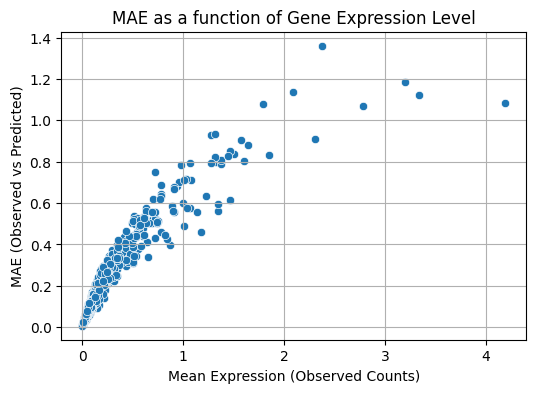

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Remove synthetic gene
observed_all_no_synth = np.delete(observed_all, synthetic_indices, axis=1)
predicted_all_no_synth = np.delete(predicted_all, synthetic_indices, axis=1)

# Compute MAE per gene
mae_per_gene = np.mean(np.abs(observed_all_no_synth - predicted_all_no_synth), axis=0)

# Compute average observed expression per gene
mean_expr_per_gene = np.mean(observed_all_no_synth, axis=0)

# Scatter plot: MAE vs Mean Expression
plt.figure(figsize=(6, 4))
sns.scatterplot(x=mean_expr_per_gene, y=mae_per_gene)
plt.xlabel("Mean Expression (Observed Counts)")
plt.ylabel("MAE (Observed vs Predicted)")
plt.title("MAE as a function of Gene Expression Level")
plt.grid(True)
plt.show()

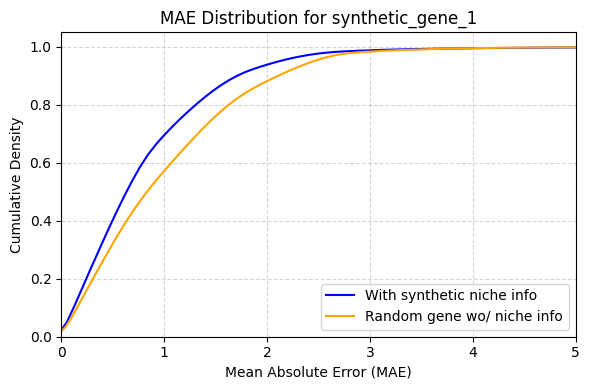

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(6, 4))
ALPHA = 1

# Use consistent colors
COLOR_SYNTH = "blue"
COLOR_RANDOM = "orange"
COLOR_ALL_GENES = "gray"

# KDE plots (Cumulative Distribution Function)
sns.kdeplot(
    mae_synth.flatten(), label="With synthetic niche info", fill=False, color=COLOR_SYNTH, alpha=ALPHA, cumulative=True
)
sns.kdeplot(
    mae_random.flatten(), label="Random gene wo/ niche info", color=COLOR_RANDOM, fill=False, alpha=ALPHA, cumulative=True
)
# Optional: Uncomment below if you want the third group
# sns.kdeplot(mae_all_genes_random, label="All other genes", color=COLOR_ALL_GENES, fill=True, alpha=0.1, cumulative=True)

# Formatting
plt.title("MAE Distribution for synthetic_gene_1")
plt.xlabel("Mean Absolute Error (MAE)")
plt.ylabel("Cumulative Density")
plt.xlim(0, 5)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(f"{FIGURES_FOLDER}/mae_distribution_synthetic_gene.png", dpi=300)
plt.savefig(f"{FIGURES_FOLDER}/mae_distribution_synthetic_gene.svg")
plt.show()

In [18]:
from scipy.stats import wilcoxon

mae_1 = mae_synth.flatten()
mae_2 = mae_random.flatten()

stat, p = wilcoxon(mae_1, mae_2, alternative="less")
# alternative='greater' tests median(mae1 - mae2) > 0

print(p)

0.0
